# Algorytmy macierzowe — lab 2

## Cel laboratorium
Celem laboratorium było zaimplementowanie i przetestowanie algorytmów Rekurencyjnego odwracania Macierzy, Rekurencyjnej eliminacji Gaussa oraz Rekurencyjnej LU faktoryzacji wraz z liczeniem wyznacznika. Każdy pomiar wykonać mieliśmy raz z metodą Bineta, raz Strassena. Część testowa polegała głownie na określeniu zależności czasu wykonania, zużycia pamięci i liczby operacji zmiennoprzecinkowych od rozmiaru macierzy wejściowych.

## Ustalenia techniczne
Do implementacji algorytmów wykorzystaliśmy język Python w wersji 3.13. Macierze zostały zaimplementowane jako Numpy ndarrays, które dzięki swojej implementacji są szybsze od tradycyjnych Pythonowych list wielowymiarowych, jak również posiadają kilka przydatnych dla nas metod, np. do sprawdzania rozmiaru macierzy. Każdy algorytm "opakowaliśmy" w klasę, w której zapisywaliśmy informację na temat liczby wykonanych operacji zmiennoprzecinkowych oraz zużycia pamięci (tzw. wrapper). Do pomiaru czasu wykonania posłużyła nam biblioteka time. Do wizualizacji wyników wykorzystaliśmy bibliotekę matplotlib.
#### Generowanie macierzy testowych
Wygenerowaliśmy macierze kwadratowe o rozmiarach od 1 x 1 do 1000 × 1000 (po dwie każdego rozmiaru), zawierające losowe liczby zmiennoprzecinkowe z przedziału $[0.00000001, 1]$.

In [2]:
import numpy as np

matrices = [np.random.uniform(0.00000001, 1, (i, i)) for i in range(1, 1000)]

In [7]:
import matplotlib.pyplot as plt

## Odwracanie macierzy
### Opis algorytmu

Ideą algorytmu odwracania macierzy $A$ jest przekształcenie układu równań (zapisanego macierzowo) $$AX = I$$ do postaci $$IX = A^{-1}$$

Naszą macierz rozdzielamy początkowo na 4 bloki, mamy zatem:
$$
\begin{array}{cc}
\begin{bmatrix}
A_{11} & A_{12}\\
A_{21} & A_{22}
\end{bmatrix}
&
*
&
\begin{bmatrix}
X_{11} & X_{12}\\
X_{21} & X_{22}
\end{bmatrix}
&
=
&\begin{bmatrix}
I & 0\\
0 & I
\end{bmatrix}
\end{array}
$$
 Przkształceń będziemy dokonywać poprzez następujące operacje ($B = A^{-1}$):
1. $A_{11}^{-1} = inverse(A_{11})$
2. $S_{22} = A_{22} - A_{21} * A_{11}^{-1} * A_{12}$
3. $S_{22}^{-1} = inverse(S_{22})$
4. $B_{11} = A_{11}^{-1} * (I + A_{12}S_{22}^{-1}A_{21}A_{11}^{-1})$
5. $B_{12} = -A_{11}^{-1} * A_{12} * S_{22}^{-1}$
6. $B_{21} = -S_{22}^{-1} * A_{21} * A{11}^{-1}$
7. $B_{22} = S_{22}^{-1}$

Przekształcenia te są równoważne ze zmianami poszczególnych wierszy, w sposób dość podobny do znanego nam z eliminacji Gaussa (czyli np. przez pomnożenie jednego wiersza przez jakąś wielokrtoność innego).

### Fragmenty kodu

In [ ]:
def inverse(self, matrix: np.ndarray) -> np.ndarray:
    """
    Funkcja odwracająca macierz z wykorzystaniem sposobu podanego na wykładzie.
    :param matrix: Macierz do odwrócenia
    :return: Macierz odwrotna do podanej
    """
    if tuple(matrix.shape) == (1, 1):
        self.flops += 1
        return np.array([[1 / matrix[0][0]]])

    a11, a12, a21, a22 = self.split(matrix)

    a11_rev = self.inverse(a11)

    s22 = a22 - self.matmul(a21, a11_rev, a12)

    s22_rev = self.inverse(s22)

    b11 = self.matmul(a11_rev, np.eye(a11_rev.shape[0], a11_rev.shape[1]) + self.matmul(a12, s22_rev, a21, a11_rev))

    b12 = -1 * self.matmul(a11_rev, a12, s22_rev)

    b21 = -1 * self.matmul(s22_rev, a21, a11_rev)

    return np.vstack((np.hstack((b11, b12)), np.hstack((b21, s22_rev))))

## Rozkład LU i wyznacznik
### Opis algorytmu
Algorytm rozkładu LU polega na rozłożeniu macierzy $A$ na macierze $L$ (trójkątną dolną) i $U$ (trójkątną górną), takie, że
$$L * U = A$$

Zrobimy to, zauważając, że
$$
\begin{array}{cccccc}
A = \begin{bmatrix}
A_{11} & A_{12}\\
A_{21} & A_{22}
\end{bmatrix}
&
=
&
\begin{bmatrix}
I & 0\\
0 & I
\end{bmatrix}
&
\begin{bmatrix}
A_{11} & A_{12}\\
A_{21} & A_{22}
\end{bmatrix}
&
=
&
LU
\end{array}
$$
Przekształcimy te dwie macierze tak, aby lewa (jednostkowa) stała się macierzą $L$, a prawa (dotychczasowa macierz $A$) stała się macierzą $U$.

Algorytm zapisany jako lista kroków wygląda tak:
1. $[L_{11}, U_{11}] = LU(A_{11})$
2. $U_{11}^{-1} = inverse(U_{11})$
3. $L_{21} = A_{21}U_{11}^{-1}$
4. $L_{11}^{-1} = inverse(L_{11})$
5. $U_{12} = L_{11}^{-1}A_{12}$
6. $S = A_{22} - A_{21}U_{11}^{-1}L_{11}^{-1}A_{12}$
7. $[L_s, U_s] = LU(S)$
8. $U_{22} = U_s$
9. $L_{22} = L_s$

Ponownie, przekształcenia te są podobne (koncepcyjnie) do tych, które wykonujemy w trakcie eliminacji Gaussa, ewentualnie są zawołaniami rekurencyjnymi lub wykorzystującymi inwersję, opisaną w poprzednim punkcie.

Wyznacznik macierzy liczymy, wykorzystując fakt, że wyznacznik iloczynu macierzy to iloczyn wyznaczników, a wyznacznik macierzy trójkątnej to iloczyn elementów na jej przekątnej.
$$det(A) = det(LU) = det(L) * det(U) = 1 * det(U)$$


### Fragmenty kodu

In [ ]:
def lu(self, matrix: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Funkcja przeprowadzająca rozkład LU podanej macierzy.
    :param matrix: Macierz wejściowa.
    :return: Krotka macierzy L i U.
    """
    if matrix.shape[0] == 1 and matrix.shape[1] == 1:
        return np.ones_like(matrix), matrix

    a11, a12, a21, a22 = self.split(matrix)

    l11, u11 = self.lu(a11)

    u11_rev = self.inverse(u11)

    l21 = self.matmul(a21, u11_rev)

    l11_rev = self.inverse(l11)

    u12 = self.matmul(l11_rev, a12)

    l22 = a22 - self.matmul(a21, u11_rev, l11_rev, a12)

    ls, us = self.lu(l22)

    u22 = us
    l22 = ls

    lu_tuple = (np.vstack((np.hstack((l11, np.zeros((l11.shape[0], l22.shape[1])))), np.hstack((l21, l22)))),
            np.vstack((np.hstack((u11, u12)), np.hstack((np.zeros((u22.shape[0], u11.shape[1])), u22)))))
    return lu_tuple

def det(self, matrix: np.ndarray) -> float:
    """
    Funkcja obliczająca wyznacznik macierzy za pomocą rozkładu LU.
    :param matrix: Macierz wejściowa.
    :return: Wyznacznik macierzy.
    """
    _, u = self.lu(matrix)
    det = 1
    for num in [u[i][i] for i in range(u.shape[0])]:
        det *= num
    return det

def det_lu(self, u_matrix: np.ndarray) -> float:
    """
    Funkcja obliczająca wyznacznik macierzy trójkątnej górnej.
    :param u_matrix: Macierz trójkątna górna.
    :return: Wyznacznik macierzy.
    """
    det = 1
    for i, num in enumerate(u_matrix):
        det *= num[i]
    return det

## Blokowa Eliminacja Gaussa

Algorytm ten opiera się o kilka głównych kroków: 
- podzielenie macierzy na cztery blokowe części (w miare możliwości równe)
- jeśli część jest wielkości 1x1: Zwróć część
- z LU faktoryzuj lewą górną część (dostajesz L11, U11)
- części lewą górną i prawą górną przemnóż przez odwrotność L!!
- lewą dolną część zapisz, a w zwracanej macierzy wypełnij zerami
- dla prawej dolnej części oblicz S (dopełnienie Shura)
- dla S wróć do początku i oblicz jego eliminację Gaussa
- zwróć wynikową macierz postaci: 
    lewa górna część i prawa górna część przemnożone przez odwrotność L
    lewa dolna część wypełniona zerami, prawa dolna część obliczona eliminacja Gaussa z S

### Fragmenty kodu

In [ ]:
def gaussElimination(self, matrix: np.ndarray, topCall: bool = True) -> np.ndarray:
    """
    Rekurencyjna blokowa eliminacja Gaussa: dzieli macierz na bloki,
    wykonuje eliminację na bloku A11, oblicza dopełnienie Schura
    i rekurencyjnie przetwarza blok dolny prawy. Zwraca
    macierz po jednym pełnym kroku eliminacji blokowej.
    """
    A = matrix[:, :-1]
    b = matrix[:, -1]

    if A.shape == (1,1):
        return matrix

    A11, A12, A21, A22 = self.split(A)
    self.memory_used += matrix.nbytes
    n1 = A11.shape[0]

    b1 = b[:n1].reshape(-1, 1)
    b2 = b[n1:].reshape(-1, 1)

    L11, U11 = self.LU(A11)
    L11_inv = self.inverse(L11)
    U11_inv = self.inverse(U11)

    A11p = U11
    A12p = self.matmul(L11_inv, A12)
    A21p = np.zeros_like(A21)

    S = A22 - self.matmul(A21, U11_inv, A12p)
    self.memory_used += S.nbytes
    self.flops += A22.shape[0] * A22.shape[1]

    b1p = self.matmul(L11_inv, b1)
        
    b2p = b2 - self.matmul(A21, U11_inv, b1p)
    self.flops += b2.shape[0] * b2.shape[1]

    bottom = self.gaussElimination(np.column_stack((S, b2p)), topCall=False)

    A22p = bottom[:, :-1]
    b2pp = bottom[:, -1].reshape(-1, 1)

    A_top = np.hstack((A11p, A12p))
    A_bottom = np.hstack((A21p, A22p))
    A_new = np.vstack((A_top, A_bottom))

    b_new = np.concatenate((b1p, b2pp))

    self.memory_used += A_top.nbytes
    self.memory_used += A_bottom.nbytes
    self.memory_used += A_new.nbytes
    self.memory_used += b_new.nbytes
    if topCall:
        self.flops += self.inverse.flops + self.matmul.flops
        self.memory_used += self.inverse.memory_used + self.matmul.memory_used

        return np.column_stack((A_new, b_new))

In [ ]:

def split(self, matrix: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Funkcja rozdzielająca macierz na 4 (w miarę możliwości równe) części.
    :param matrix: Macierz do rozdzielenia.
    :return: 4 macierze powstałe przez rozdział tej oryginalnej
    """
    horizontal_split_point = matrix.shape[1] // 2
    vertical_split_point = matrix.shape[0] // 2

    self.memory_used += matrix.nbytes # Tworzymy 4 nowe macierze, ale w gruncie rzeczy one razem zajmują tyle pamięci co ta oryginalna
    return (matrix[:vertical_split_point, :horizontal_split_point],
            matrix[:vertical_split_point, horizontal_split_point:],
            matrix[vertical_split_point:, :horizontal_split_point],
            matrix[vertical_split_point:, horizontal_split_point:])


### Analiza algorytmu

In [4]:
from inverse import InverseWrapper
from binet import BinetWrapper
from strassen import StrassenWrapper
from time import perf_counter
from statistics import median


def measure_inverse(matrices, MultWrapperClass):

    mult_wrappers = [MultWrapperClass() for _ in range(len(matrices))]
    wrappers = [InverseWrapper(mult) for mult in mult_wrappers]

    for _ in range(3):
        for i, matrix in enumerate(matrices):

            t1 = perf_counter()
            wrappers[i].inverse(matrix)
            t2 = perf_counter()

            wrappers[i].time_used.append(t2 - t1)

            if wrappers[i].time_used[-1] > 4:
                break

    for wrapper in wrappers:
        if not wrapper.time_used:
            break

        wrapper.flops //= len(wrapper.time_used)
        wrapper.memory_used //= len(wrapper.time_used)
        wrapper.time_used = median(wrapper.time_used)

    return [
        w for w in wrappers
        if isinstance(w.time_used, float)
    ]


measurements_inverse_binet_wrappers = measure_inverse(
    matrices,
    BinetWrapper
)

measurements_inverse_strassen_wrappers = measure_inverse(
    matrices,
    StrassenWrapper
)



### Czas wykonania

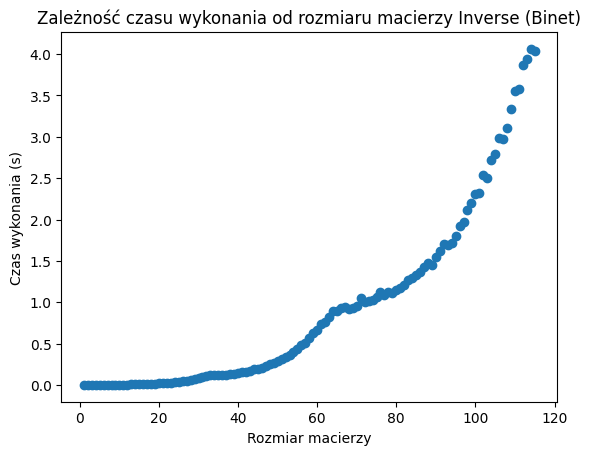

In [8]:
plt.scatter(range(1, len(measurements_inverse_binet_wrappers) + 1), [wrapper.time_used for wrapper in measurements_inverse_binet_wrappers])
plt.title("Zależność czasu wykonania od rozmiaru macierzy Inverse (Binet)")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Czas wykonania (s)")
plt.show()

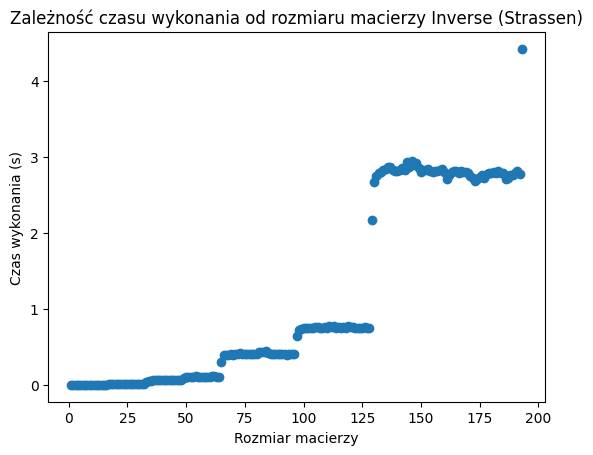

In [9]:
plt.scatter(range(1, len(measurements_inverse_strassen_wrappers) + 1), [wrapper.time_used for wrapper in measurements_inverse_strassen_wrappers])
plt.title("Zależność czasu wykonania od rozmiaru macierzy Inverse (Strassen)")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Czas wykonania (s)")
plt.show()

### Liczba operacji zmiennoprzecinkowych

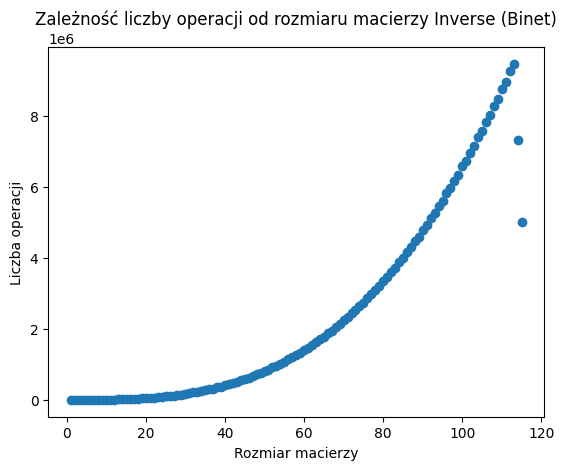

In [10]:
plt.scatter(range(1, len(measurements_inverse_binet_wrappers) + 1), [wrapper.flops for wrapper in measurements_inverse_binet_wrappers])
plt.title("Zależność liczby operacji od rozmiaru macierzy Inverse (Binet)")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Liczba operacji")
plt.show()

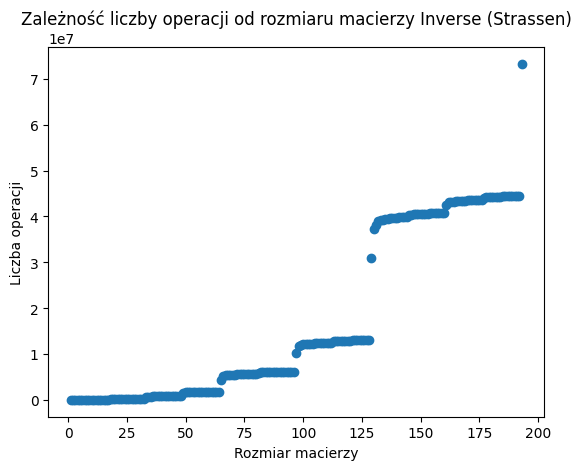

In [11]:
plt.scatter(range(1, len(measurements_inverse_strassen_wrappers) + 1), [wrapper.flops for wrapper in measurements_inverse_strassen_wrappers])
plt.title("Zależność liczby operacji od rozmiaru macierzy Inverse (Strassen)")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Liczba operacji")
plt.show()

### Zużycie pamięci

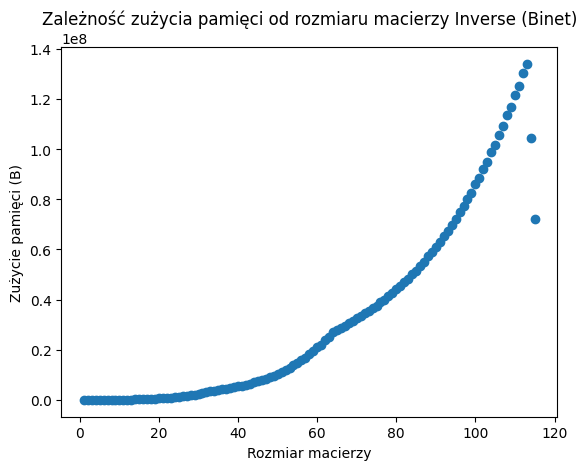

In [12]:
plt.scatter(range(1, len(measurements_inverse_binet_wrappers) + 1), [wrapper.memory_used for wrapper in measurements_inverse_binet_wrappers])
plt.title("Zależność zużycia pamięci od rozmiaru macierzy Inverse (Binet)")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Zużycie pamięci (B)")
plt.show()

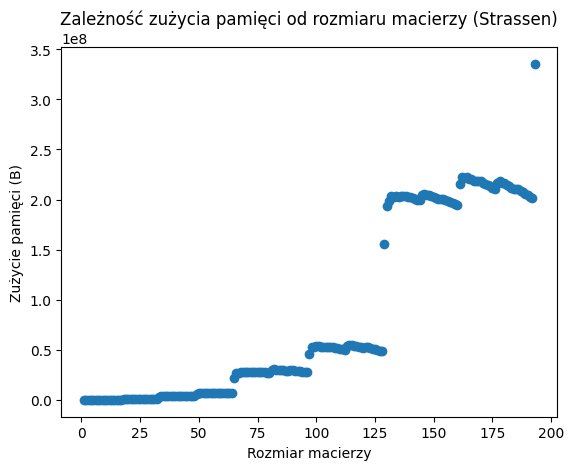

In [13]:
plt.scatter(range(1, len(measurements_inverse_strassen_wrappers) + 1), [wrapper.memory_used for wrapper in measurements_inverse_strassen_wrappers])
plt.title("Zależność zużycia pamięci od rozmiaru macierzy (Strassen)")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Zużycie pamięci (B)")
plt.show()

In [16]:
from lu import LUWrapper

def measure_lu(matrices, MultWrapperClass):
    """
    matrices: lista macierzy
    MultWrapperClass: BinetWrapper lub StrassenWrapper
    """

    mult_wrappers = [MultWrapperClass() for _ in range(len(matrices))]

    wrappers = [LUWrapper(mult) for mult in mult_wrappers]

    for _ in range(3):
        for i, matrix_a in enumerate(matrices):

            t1 = perf_counter()
            wrappers[i].lu(matrix_a)
            t2 = perf_counter()

            wrappers[i].time_used.append(t2 - t1)

            if wrappers[i].time_used[-1] > 4:
                break

    for wrapper in wrappers:
        if not wrapper.time_used:
            break

        wrapper.flops //= len(wrapper.time_used)
        wrapper.memory_used //= len(wrapper.time_used)
        wrapper.time_used = median(wrapper.time_used)

    return [
        w for w in wrappers
        if isinstance(w.time_used, float)
    ]


measurements_lu_binet_wrappers = measure_lu(
    matrices,
    BinetWrapper
)

measurements_lu_strassen_wrappers = measure_lu(
    matrices,
    StrassenWrapper
)

### Czas wykonania

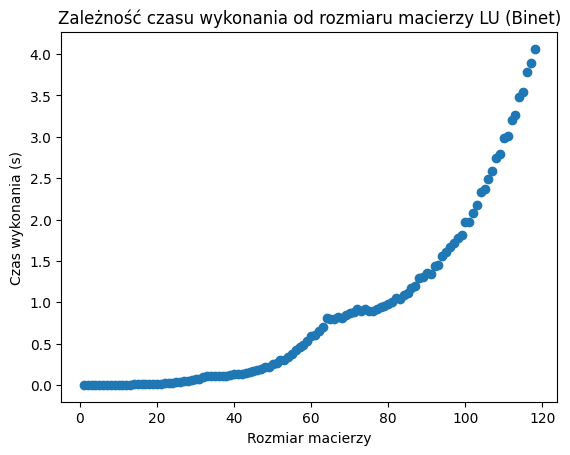

In [17]:
plt.scatter(range(1, len(measurements_lu_binet_wrappers) + 1), [wrapper.time_used for wrapper in measurements_lu_binet_wrappers])
plt.title("Zależność czasu wykonania od rozmiaru macierzy LU (Binet)")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Czas wykonania (s)")
plt.show()

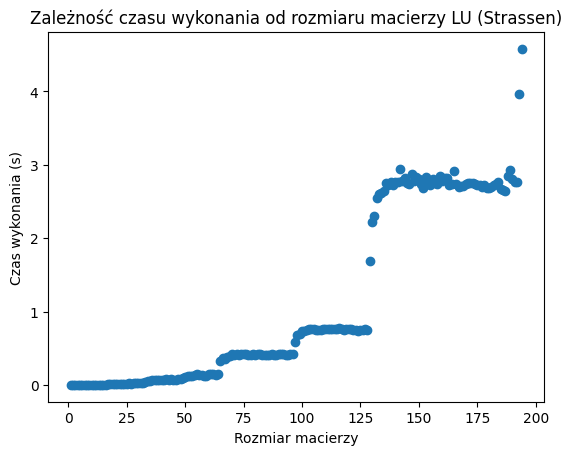

In [18]:
plt.scatter(range(1, len(measurements_lu_strassen_wrappers) + 1), [wrapper.time_used for wrapper in measurements_lu_strassen_wrappers])
plt.title("Zależność czasu wykonania od rozmiaru macierzy LU (Strassen)")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Czas wykonania (s)")
plt.show()

### Liczba operacji zmiennoprzecinkowych

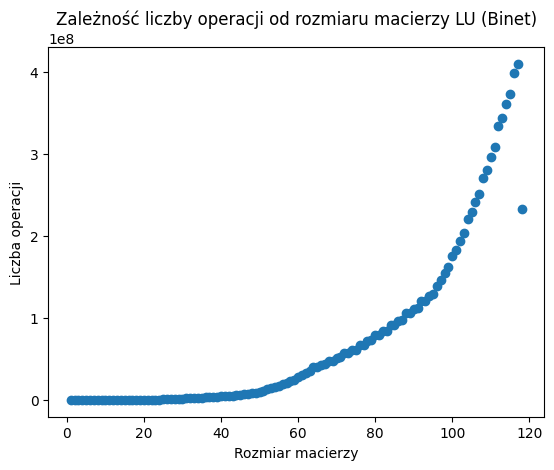

In [19]:
plt.scatter(range(1, len(measurements_lu_binet_wrappers) + 1), [wrapper.flops for wrapper in measurements_lu_binet_wrappers])
plt.title("Zależność liczby operacji od rozmiaru macierzy LU (Binet)")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Liczba operacji")
plt.show()

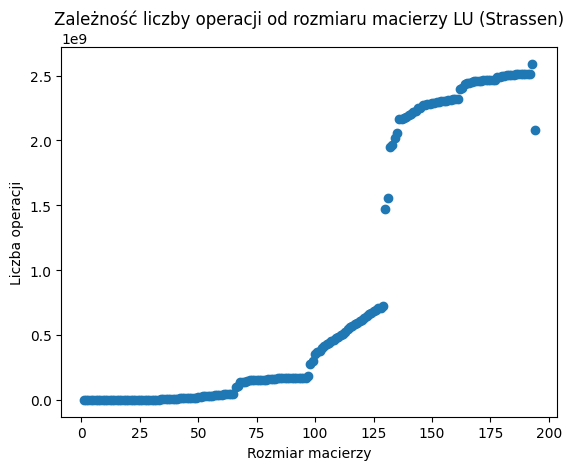

In [20]:
plt.scatter(range(1, len(measurements_lu_strassen_wrappers) + 1), [wrapper.flops for wrapper in measurements_lu_strassen_wrappers])
plt.title("Zależność liczby operacji od rozmiaru macierzy LU (Strassen)")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Liczba operacji")
plt.show()

### Zużycie pamięci

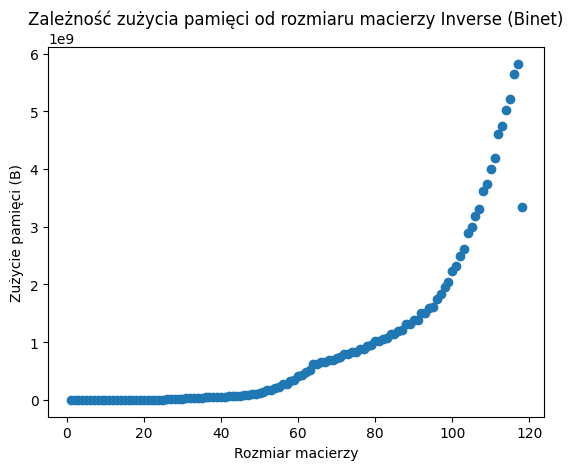

In [21]:
plt.scatter(range(1, len(measurements_lu_binet_wrappers) + 1), [wrapper.memory_used for wrapper in measurements_lu_binet_wrappers])
plt.title("Zależność zużycia pamięci od rozmiaru macierzy Inverse (Binet)")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Zużycie pamięci (B)")
plt.show()

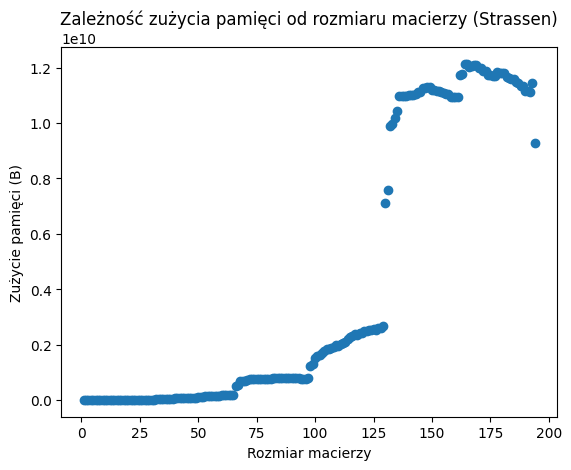

In [ ]:
plt.scatter(range(1, len(measurements_lu_strassen_wrappers) + 1), [wrapper.memory_used for wrapper in measurements_lu_strassen_wrappers])
plt.title("Zależność zużycia pamięci od rozmiaru macierzy LU (Strassen)")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Zużycie pamięci (B)")
plt.show()

### Liczba operacji zmiennoprzecinkowych podzielona przez czas działania w sekundach

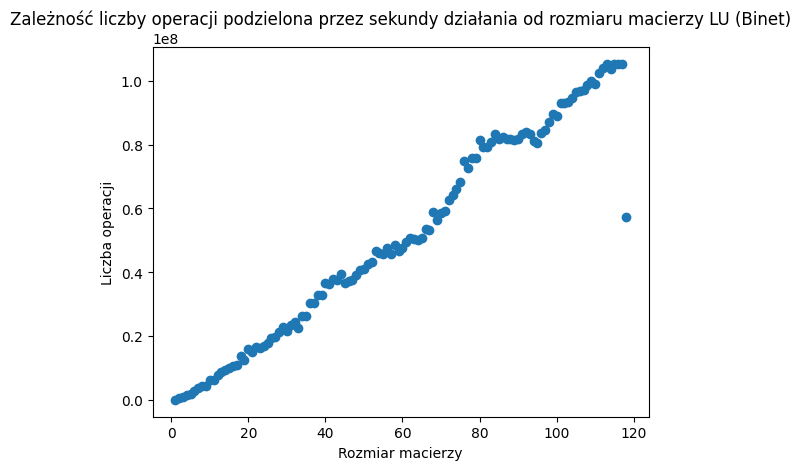

In [28]:
plt.scatter(range(1, len(measurements_lu_binet_wrappers) + 1), [wrapper.flops/wrapper.time_used for wrapper in measurements_lu_binet_wrappers])
plt.title("Zależność liczby operacji podzielona przez sekundy działania od rozmiaru macierzy LU (Binet)")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Liczba operacji")
plt.show()

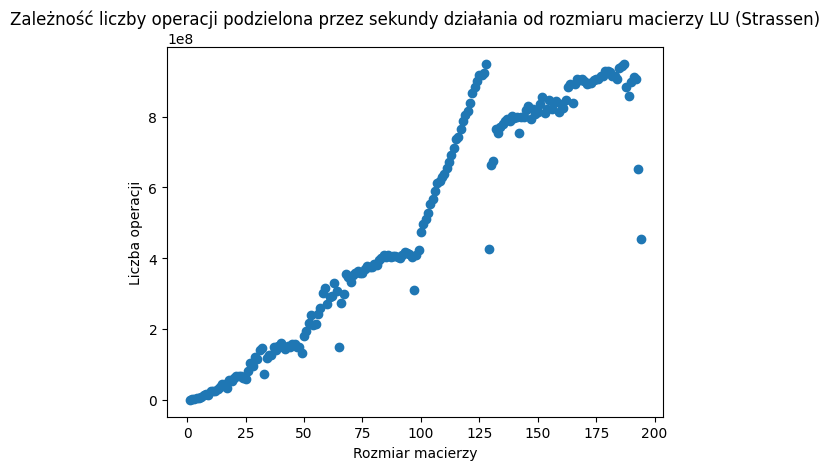

In [30]:
plt.scatter(range(1, len(measurements_lu_strassen_wrappers) + 1), [wrapper.flops/wrapper.time_used for wrapper in measurements_lu_strassen_wrappers])
plt.title("Zależność liczby operacji podzielona przez sekundy działania od rozmiaru macierzy LU (Strassen)")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Liczba operacji")
plt.show()

In [27]:
gauss_matrices = [np.random.uniform(0.00000001, 1, (i, i+1)) for i in range(1, 1000)]

In [33]:
from gauss_elimination import GaussWrapper
def measure_gauss(matrices, MultWrapperClass):
    """
    matrices: lista macierzy A
    MultWrapperClass: BinetWrapper lub StrassenWrapper
    """

    mult_wrappers = [MultWrapperClass() for _ in range(len(matrices))]

    wrappers = [GaussWrapper(mult) for mult in mult_wrappers]

    for _ in range(3):
        for i, matrix_a in enumerate(gauss_matrices):

            t1 = perf_counter()
            wrappers[i].gaussElimination(matrix_a)
            t2 = perf_counter()

            wrappers[i].time_used.append(t2 - t1)

            if wrappers[i].time_used[-1] > 4:
                break

    for wrapper in wrappers:
        if not wrapper.time_used:
            break

        wrapper.flops //= len(wrapper.time_used)
        wrapper.memory_used //= len(wrapper.time_used)
        wrapper.time_used = median(wrapper.time_used)

    return [
        w for w in wrappers
        if isinstance(w.time_used, float)
    ]


measurements_gauss_binet_wrappers = measure_gauss(
    matrices,
    BinetWrapper
)

measurements_gauss_strassen_wrappers = measure_gauss(
    matrices,
    StrassenWrapper
)

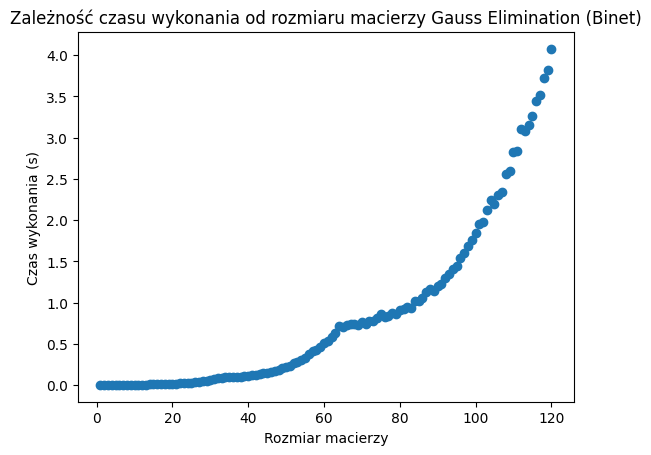

In [34]:
plt.scatter(range(1, len(measurements_gauss_binet_wrappers) + 1), [wrapper.time_used for wrapper in measurements_gauss_binet_wrappers])
plt.title("Zależność czasu wykonania od rozmiaru macierzy Gauss Elimination (Binet)")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Czas wykonania (s)")
plt.show()

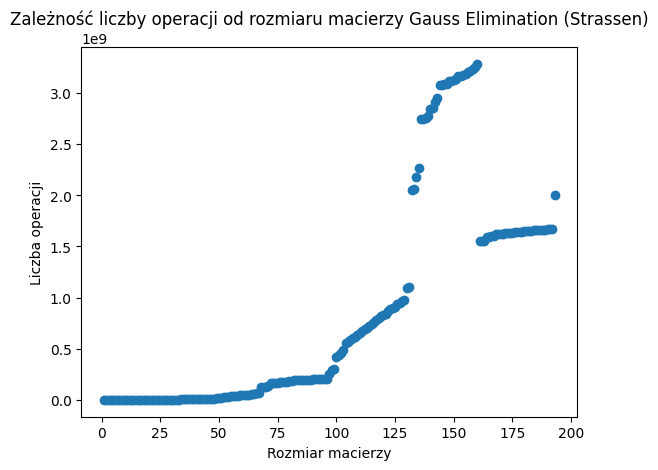

In [35]:
plt.scatter(range(1, len(measurements_gauss_strassen_wrappers) + 1), [wrapper.flops for wrapper in measurements_gauss_strassen_wrappers])
plt.title("Zależność liczby operacji od rozmiaru macierzy Gauss Elimination (Strassen)")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Liczba operacji")
plt.show()

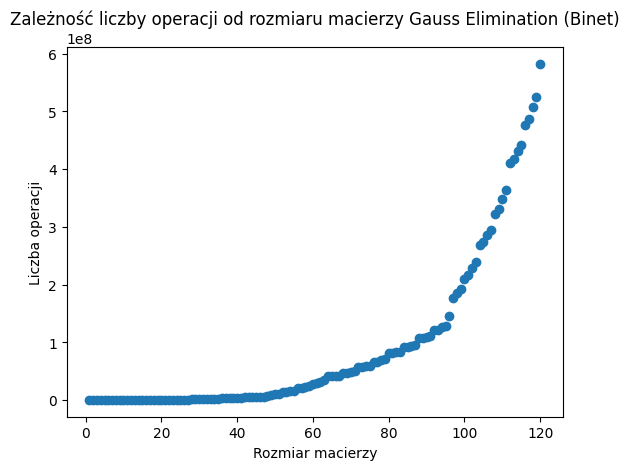

In [36]:
plt.scatter(range(1, len(measurements_gauss_binet_wrappers) + 1), [wrapper.flops for wrapper in measurements_gauss_binet_wrappers])
plt.title("Zależność liczby operacji od rozmiaru macierzy Gauss Elimination (Binet)")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Liczba operacji")
plt.show()

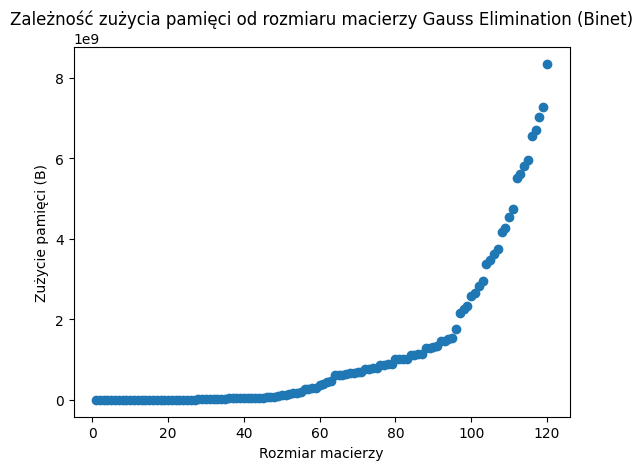

In [37]:
plt.scatter(range(1, len(measurements_gauss_binet_wrappers) + 1), [wrapper.memory_used for wrapper in measurements_gauss_binet_wrappers])
plt.title("Zależność zużycia pamięci od rozmiaru macierzy Gauss Elimination (Binet)")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Zużycie pamięci (B)")
plt.show()

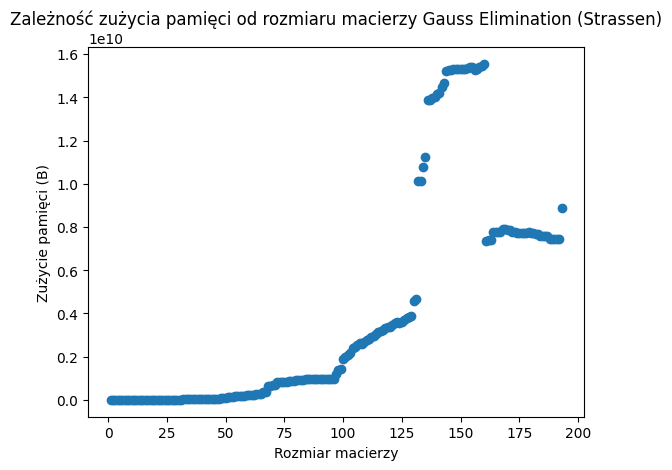

In [38]:
plt.scatter(range(1, len(measurements_gauss_strassen_wrappers) + 1), [wrapper.memory_used for wrapper in measurements_gauss_strassen_wrappers])
plt.title("Zależność zużycia pamięci od rozmiaru macierzy Gauss Elimination (Strassen)")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Zużycie pamięci (B)")
plt.show()

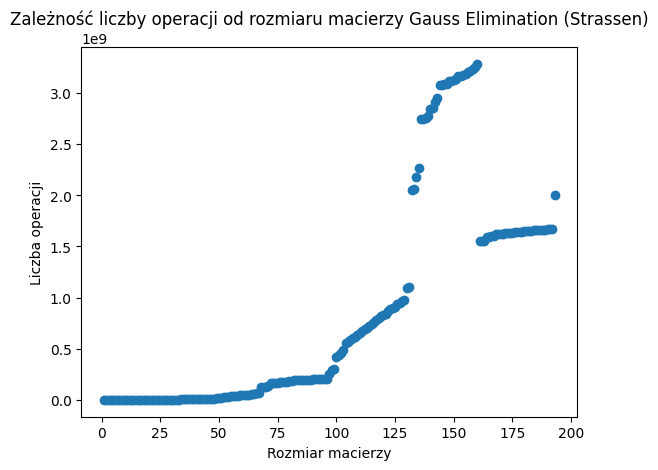

In [39]:
plt.scatter(range(1, len(measurements_gauss_strassen_wrappers) + 1), [wrapper.flops for wrapper in measurements_gauss_strassen_wrappers])
plt.title("Zależność liczby operacji od rozmiaru macierzy Gauss Elimination (Strassen)")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Liczba operacji")
plt.show()

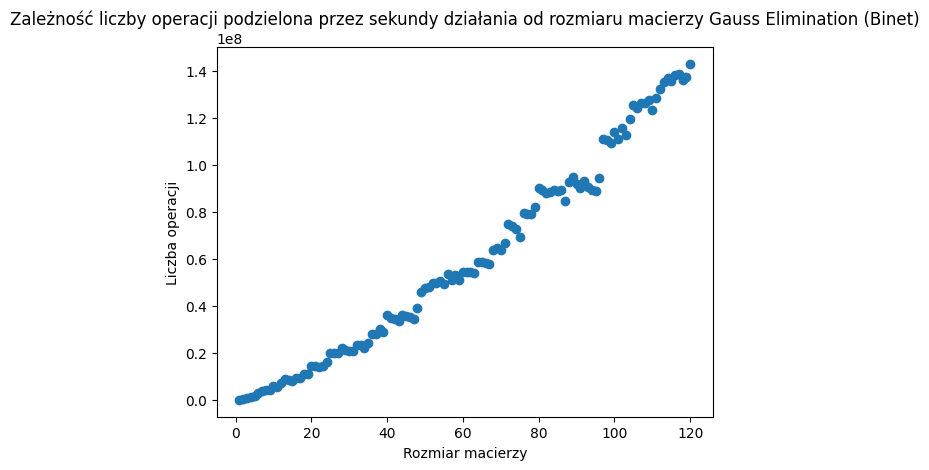

In [40]:
plt.scatter(range(1, len(measurements_gauss_binet_wrappers) + 1), [wrapper.flops/wrapper.time_used for wrapper in measurements_gauss_binet_wrappers])
plt.title("Zależność liczby operacji podzielona przez sekundy działania od rozmiaru macierzy Gauss Elimination (Binet)")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Liczba operacji")
plt.show()

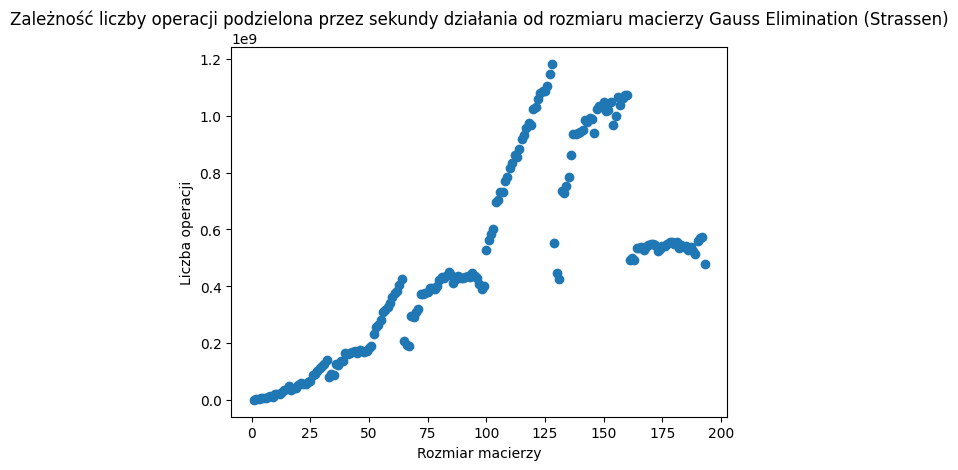

In [41]:
plt.scatter(range(1, len(measurements_gauss_strassen_wrappers) + 1), [wrapper.flops/wrapper.time_used for wrapper in measurements_gauss_strassen_wrappers])
plt.title("Zależność liczby operacji podzielona przez sekundy działania od rozmiaru macierzy Gauss Elimination (Strassen)")
plt.xlabel("Rozmiar macierzy")
plt.ylabel("Liczba operacji")
plt.show()